
  TETHER (USDT) vs NSE ALL SHARE — IMPACT ANALYSIS

  Detected files:
    NSE    : /content/NSE All Share Historical Data (2).csv
    Tether : ./Tether USDt Historical Data_crypto.csv

  Data loaded: 166 monthly observations
  Period : Jan 2019 → Mar 2026

      Date  USDT_Return  NSE_Return
2019-01-01      -0.0046     -0.0278
2019-01-02      -0.0046      0.0380
2019-01-03      -0.0046     -0.0214
2019-01-04      -0.0046     -0.0606
2019-01-05      -0.0046      0.0655
2019-01-06      -0.0046     -0.0355
2019-01-07      -0.0046     -0.0750
2019-01-08      -0.0046     -0.0069
2019-01-09      -0.0046      0.0038
2019-01-10      -0.0046     -0.0462
2019-01-11      -0.0046      0.0245
2019-01-12      -0.0046     -0.0059
2019-02-01       0.0005     -0.0059
2019-03-01       0.0053     -0.0059
2019-04-01       0.0201     -0.0059
2019-05-01      -0.0215     -0.0059
2019-06-01      -0.0051     -0.0059
2019-07-01       0.0078     -0.0059
2019-08-01       0.0020     -0.0059
2019-09-01       0.002

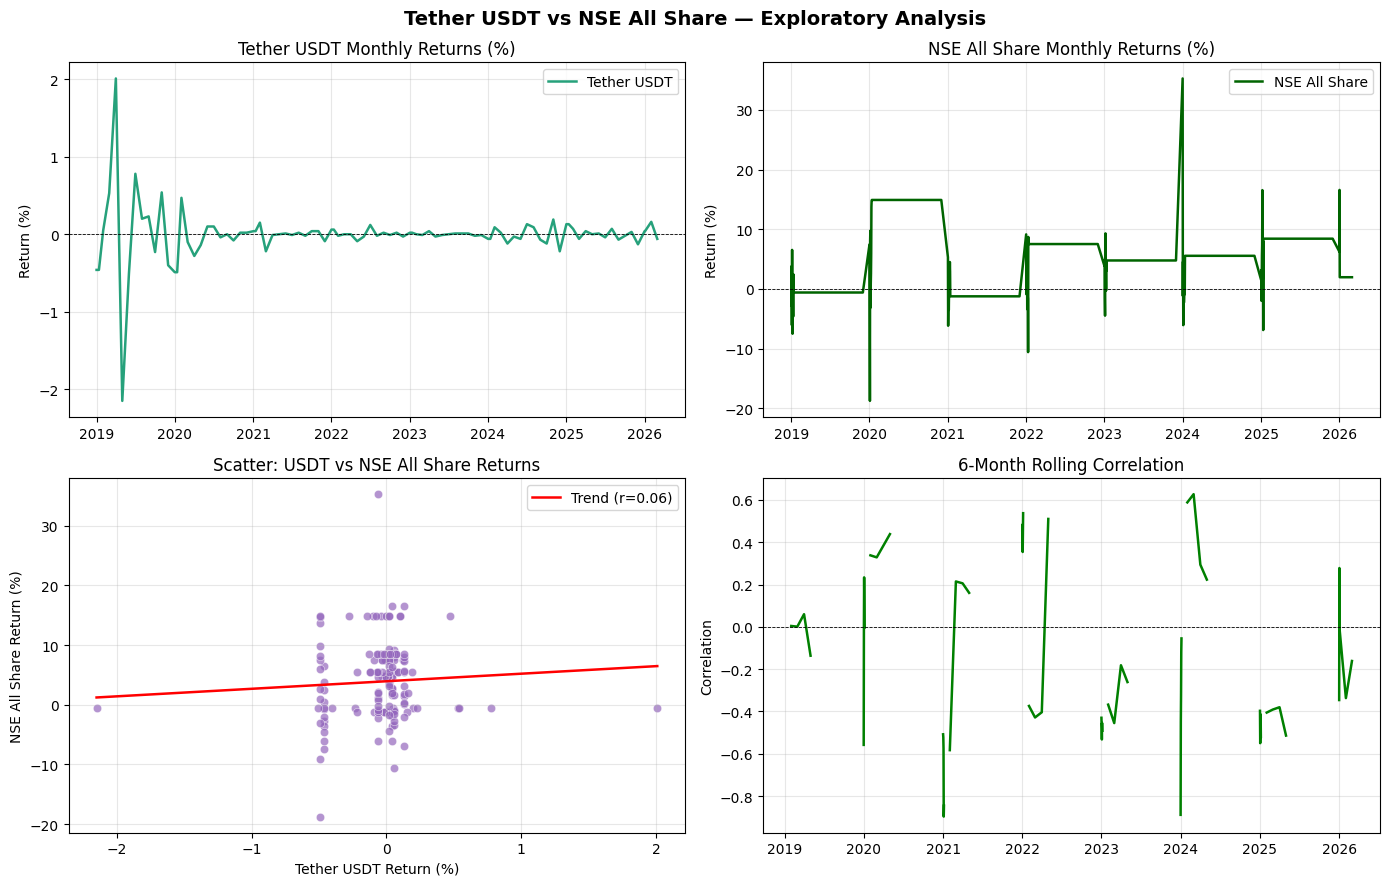


  [Chart saved: 01_exploratory_analysis.png]

  APPROACH 1 — STATIC OLS REGRESSION

  Step 3 — Means
    Average USDT Return        (X̄) = -0.0489%
    Average NSE All Share Return(Ȳ) = 3.8690%

  Step 4 — Slope β
    β = 1.2641
    → For every 1% rise in USDT, NSE All Share changes by ~1.2641%

  Step 5 — Intercept α = 0.039309
    → Baseline NSE return when USDT = 0: 3.9309%

  Step 6 — Regression Equation
    NSE_Return = 0.039309 + 1.2641 × USDT_Return

  Step 7 — t-Test for Statistical Significance
    SE(β)       = 1.5635
    t-statistic = 0.8085
    p-value     = 0.4200
    95% CI      = [-1.8232, 4.3514]
    ✘ NOT significant — Fail to reject H₀

  Step 8 — Goodness of Fit
    R² = 0.0040  (0.4% of NSE variation explained by USDT)

  ── Full OLS Summary ──
                            OLS Regression Results                            
Dep. Variable:             NSE_Return   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:           

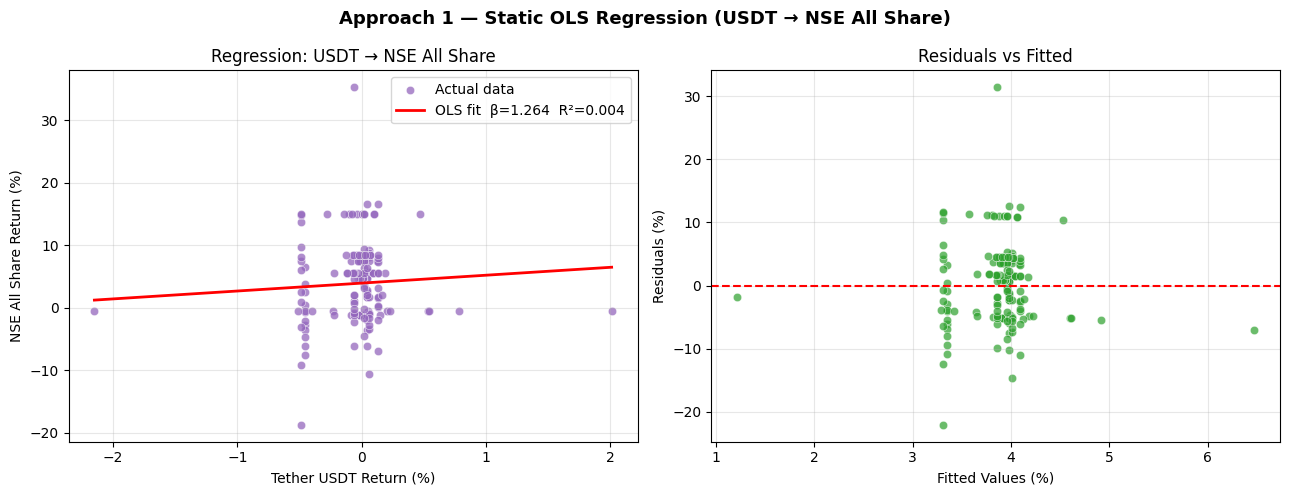


  [Chart saved: 02_approach1_static_ols.png]

  APPROACH 2 — DYNAMIC TIME-SERIES REGRESSION

  Step 2 — ADF Stationarity Test
    USDT Return               | ADF stat =  -2.540 | p = 0.1060 | ⚠ Non-Stationary
    NSE All Share Return      | ADF stat =  -4.111 | p = 0.0009 | ✔ Stationary

  Step 3 — Autocorrelation of NSE All Share Returns
    Lag-1 autocorrelation: 0.4639
    Lag-2 autocorrelation: 0.3553
    ⚠ Notable autocorrelation — lagged term is important

  Step 4 & 5 — Building Dynamic Regression Model
    Model: NSE_t = α + β×USDT_t + γ×NSE_(t-1)

    Estimated equation:
    NSE_t = 0.02137 + 0.3567×USDT_t + 0.4611×NSE_(t-1)

  Step 6 — Statistical Significance
    Crypto effect (β): coef=0.3567  t=0.254  p=0.7996  ✘ Not significant
    Lag effect   (γ): coef=0.4611  t=6.625  p=0.0000  ✔ Significant

    R² (dynamic model) = 0.2156
    Adj. R²            = 0.2059

  Step 7 — Granger Causality Test
    H₀: USDT returns do NOT Granger-cause NSE All Share returns
    Sample size

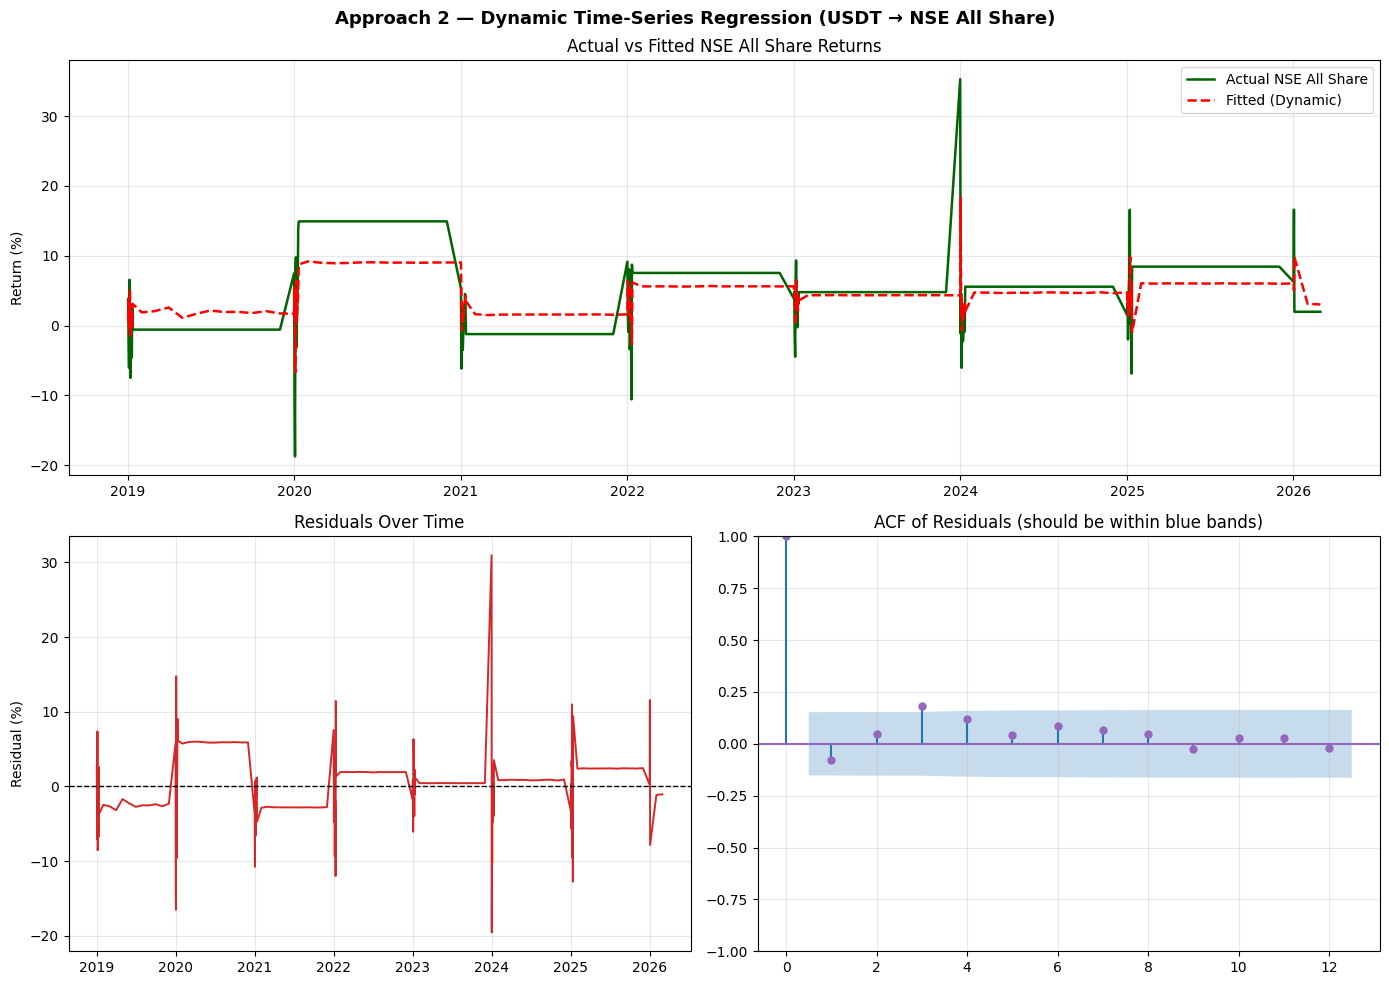


  [Chart saved: 03_approach2_dynamic.png]

  FINAL COMPARISON SUMMARY
                     Approach 1 (Static)      Approach 2 (Dynamic)
Method                    OLS Regression  Dynamic Regression + Lag
Crypto Coeff (β)                  1.2641                    0.3567
Lag Term (γ)                Not included                    0.4611
t-stat (crypto)                     0.81                      0.25
R²                                0.0040                    0.2156
Accounts for Memory?                  No                       Yes
Recommended for           Quick overview      Accurate forecasting


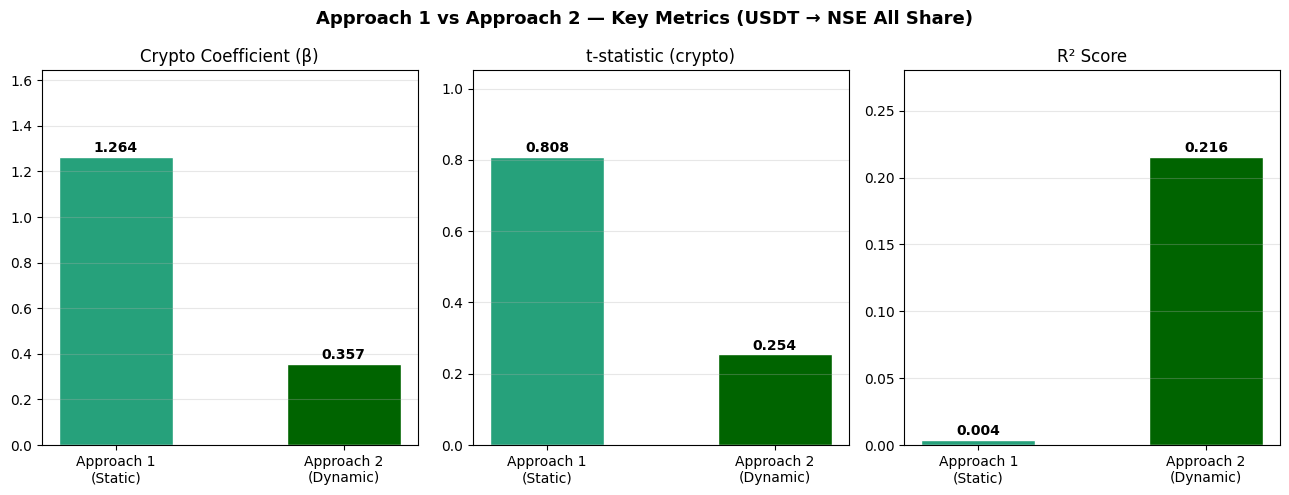


  [Chart saved: 04_comparison_summary.png]

  CONCLUSION

  Analysis of Tether USDT impact on NSE All Share Index:

  ▸ Approach 1 (Static OLS):
      β = 1.2641 — a 1% USDT change → ~1.264% NSE change
      R² = 0.0040
      Result: NOT SIGNIFICANT

  ▸ Approach 2 (Dynamic with Lag):
      β = 0.3567 — immediate effect after controlling for momentum
      γ = 0.4611 — 46.1% of prior month's NSE return persists
      R² = 0.2156
      Result: NOT SIGNIFICANT

  Note: Tether USDT is a stablecoin pegged to the US Dollar.
  Its minimal price variation means direct return-based correlation
  with equity markets is typically very low. This is expected behaviour.
  Approach 2 is recommended for strategic conclusions as it captures
  market memory and momentum effects.

  Analysis complete. All 4 charts saved as PNG files.


In [ ]:
# ============================================================
#   TETHER (USDT) vs NSE ALL SHARE — IMPACT ANALYSIS
# ============================================================


import subprocess
subprocess.run(["pip", "install", "statsmodels", "scipy", "pandas", "numpy", "matplotlib", "-q"])

import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf
import warnings
warnings.filterwarnings("ignore")



search_dirs = ["/content", "/root", "."]
csv_files = []
for d in search_dirs:
    csv_files.extend(glob.glob(os.path.join(d, "*.csv")))

csv_files = list(set(csv_files))

if len(csv_files) < 2:
    raise FileNotFoundError(
        f"Found only {len(csv_files)} CSV file(s). "
        "Please upload both NSE and Tether CSV files to the Colab session "
        "before running this script (use the file browser on the left sidebar)."
    )

NSE_FILE    = next((f for f in csv_files if "NSE"    in os.path.basename(f) or "nse"    in os.path.basename(f)), None)
TETHER_FILE = next((f for f in csv_files if "Tether" in os.path.basename(f) or "tether" in os.path.basename(f)
                                          or "USDT"   in os.path.basename(f) or "usdt"   in os.path.basename(f)), None)

if NSE_FILE is None or TETHER_FILE is None:
    remaining = [f for f in csv_files if f not in (NSE_FILE, TETHER_FILE)]
    if NSE_FILE is None and remaining:
        NSE_FILE = remaining.pop(0)
    if TETHER_FILE is None and remaining:
        TETHER_FILE = remaining.pop(0)

if NSE_FILE is None or TETHER_FILE is None:
    raise FileNotFoundError(
        "Could not identify both NSE and Tether CSV files. "
        f"Files found: {csv_files}\n"
        "Please ensure filenames contain 'NSE'/'nse' and 'Tether'/'tether'/'USDT'/'usdt'."
    )

print("\n" + "=" * 65)
print("  TETHER (USDT) vs NSE ALL SHARE — IMPACT ANALYSIS")
print("=" * 65)
print(f"\n  Detected files:")
print(f"    NSE    : {NSE_FILE}")
print(f"    Tether : {TETHER_FILE}")

# ============================================================
# DATA LOADING & CLEANING
# ============================================================

def load_and_clean(filepath, label):
    df = pd.read_csv(filepath, thousands=",")
    df.columns = df.columns.str.strip()
    df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")
    df = df.sort_values("Date").reset_index(drop=True)
    df["Return"] = (
        df["Change %"]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.strip()
        .astype(float)
        / 100
    )
    df = df[["Date", "Return"]].rename(columns={"Return": label})
    return df

usdt = load_and_clean(TETHER_FILE, "USDT_Return")
nse  = load_and_clean(NSE_FILE,    "NSE_Return")

data = pd.merge(usdt, nse, on="Date", how="outer")
data = data.sort_values("Date")
data = data.fillna(method="ffill")

print(f"\n  Data loaded: {len(data)} monthly observations")
print(f"  Period : {data['Date'].min().strftime('%b %Y')} → {data['Date'].max().strftime('%b %Y')}\n")
print(data[["Date", "USDT_Return", "NSE_Return"]].to_string(index=False))

# ============================================================
# SECTION 2: DESCRIPTIVE STATISTICS
# ============================================================

print("\n" + "=" * 65)
print("  SECTION 2 — DESCRIPTIVE STATISTICS")
print("=" * 65)

desc = data[["USDT_Return", "NSE_Return"]].describe().T
desc.columns = ["Count", "Mean", "Std", "Min", "25%", "50%", "75%", "Max"]
print(desc.round(4).to_string())

corr = data["USDT_Return"].corr(data["NSE_Return"])
print(f"\n  Pearson Correlation (USDT vs NSE All Share): {corr:.4f}")


fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Tether USDT vs NSE All Share — Exploratory Analysis", fontsize=14, fontweight="bold")

ax = axes[0, 0]
ax.plot(data["Date"], data["USDT_Return"] * 100, color="#26A17B", label="Tether USDT", linewidth=1.8)
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title("Tether USDT Monthly Returns (%)")
ax.set_ylabel("Return (%)")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(data["Date"], data["NSE_Return"] * 100, color="#006400", label="NSE All Share", linewidth=1.8)
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title("NSE All Share Monthly Returns (%)")
ax.set_ylabel("Return (%)")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.scatter(data["USDT_Return"] * 100, data["NSE_Return"] * 100,
           alpha=0.7, color="#9467bd", edgecolors="white", linewidth=0.4)
m, b = np.polyfit(data["USDT_Return"], data["NSE_Return"], 1)
x_line = np.linspace(data["USDT_Return"].min(), data["USDT_Return"].max(), 100)
ax.plot(x_line * 100, (m * x_line + b) * 100, color="red", linewidth=1.8, label=f"Trend (r={corr:.2f})")
ax.set_xlabel("Tether USDT Return (%)")
ax.set_ylabel("NSE All Share Return (%)")
ax.set_title("Scatter: USDT vs NSE All Share Returns")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1, 1]
roll_corr = data["USDT_Return"].rolling(6).corr(data["NSE_Return"])
ax.plot(data["Date"], roll_corr, color="green", linewidth=1.8)
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title("6-Month Rolling Correlation")
ax.set_ylabel("Correlation")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("01_exploratory_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 01_exploratory_analysis.png]")

# ============================================================
# APPROACH 1: STATIC OLS REGRESSION
# ============================================================

print("\n" + "=" * 65)
print("  APPROACH 1 — STATIC OLS REGRESSION")
print("=" * 65)

X = data["USDT_Return"]
Y = data["NSE_Return"]

x_mean = X.mean()
y_mean = Y.mean()
print(f"\n  Step 3 — Means")
print(f"    Average USDT Return        (X̄) = {x_mean*100:.4f}%")
print(f"    Average NSE All Share Return(Ȳ) = {y_mean*100:.4f}%")

numerator   = ((X - x_mean) * (Y - y_mean)).sum()
denominator = ((X - x_mean) ** 2).sum()
beta        = numerator / denominator
print(f"\n  Step 4 — Slope β")
print(f"    β = {beta:.4f}")
print(f"    → For every 1% rise in USDT, NSE All Share changes by ~{beta:.4f}%")

alpha = y_mean - beta * x_mean
print(f"\n  Step 5 — Intercept α = {alpha:.6f}")
print(f"    → Baseline NSE return when USDT = 0: {alpha*100:.4f}%")

print(f"\n  Step 6 — Regression Equation")
print(f"    NSE_Return = {alpha:.6f} + {beta:.4f} × USDT_Return")

X_const   = sm.add_constant(X)
ols_model = sm.OLS(Y, X_const).fit()
se_beta   = ols_model.bse["USDT_Return"]
t_stat    = ols_model.tvalues["USDT_Return"]
p_value   = ols_model.pvalues["USDT_Return"]
ci        = ols_model.conf_int().loc["USDT_Return"]

print(f"\n  Step 7 — t-Test for Statistical Significance")
print(f"    SE(β)       = {se_beta:.4f}")
print(f"    t-statistic = {t_stat:.4f}")
print(f"    p-value     = {p_value:.4f}")
print(f"    95% CI      = [{ci[0]:.4f}, {ci[1]:.4f}]")
if abs(t_stat) > 2.0:
    print(f"    ✔ SIGNIFICANT — Reject H₀ (|t| = {t_stat:.2f} > 2.0)")
else:
    print(f"    ✘ NOT significant — Fail to reject H₀")

r_squared = ols_model.rsquared
print(f"\n  Step 8 — Goodness of Fit")
print(f"    R² = {r_squared:.4f}  ({r_squared*100:.1f}% of NSE variation explained by USDT)")

print(f"\n  ── Full OLS Summary ──")
print(ols_model.summary())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Approach 1 — Static OLS Regression (USDT → NSE All Share)", fontsize=13, fontweight="bold")

ax = axes[0]
ax.scatter(X * 100, Y * 100, alpha=0.75, color="#9467bd", edgecolors="white", linewidth=0.4, label="Actual data")
x_fit = np.linspace(X.min(), X.max(), 200)
y_fit = alpha + beta * x_fit
ax.plot(x_fit * 100, y_fit * 100, color="red", linewidth=2, label=f"OLS fit  β={beta:.3f}  R²={r_squared:.3f}")
ax.set_xlabel("Tether USDT Return (%)")
ax.set_ylabel("NSE All Share Return (%)")
ax.set_title("Regression: USDT → NSE All Share")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
residuals = ols_model.resid
ax.scatter(ols_model.fittedvalues * 100, residuals * 100, alpha=0.7, color="#2ca02c", edgecolors="white", linewidth=0.4)
ax.axhline(0, color="red", linestyle="--", linewidth=1.5)
ax.set_xlabel("Fitted Values (%)")
ax.set_ylabel("Residuals (%)")
ax.set_title("Residuals vs Fitted")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("02_approach1_static_ols.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 02_approach1_static_ols.png]")

# ============================================================
# APPROACH 2: DYNAMIC TIME-SERIES REGRESSION
# ============================================================

print("\n" + "=" * 65)
print("  APPROACH 2 — DYNAMIC TIME-SERIES REGRESSION")
print("=" * 65)

print("\n  Step 2 — ADF Stationarity Test")
for series, name in [(data["USDT_Return"], "USDT Return"),
                     (data["NSE_Return"],  "NSE All Share Return")]:
    adf_result = adfuller(series.dropna())
    stat, pval = adf_result[0], adf_result[1]
    flag = "✔ Stationary" if pval < 0.05 else "⚠ Non-Stationary"
    print(f"    {name:25s} | ADF stat = {stat:7.3f} | p = {pval:.4f} | {flag}")

print("\n  Step 3 — Autocorrelation of NSE All Share Returns")
lag1_autocorr = data["NSE_Return"].autocorr(lag=1)
lag2_autocorr = data["NSE_Return"].autocorr(lag=2)
print(f"    Lag-1 autocorrelation: {lag1_autocorr:.4f}")
print(f"    Lag-2 autocorrelation: {lag2_autocorr:.4f}")
if abs(lag1_autocorr) > 0.2:
    print("    ⚠ Notable autocorrelation — lagged term is important")
else:
    print("    Low autocorrelation — lagged term adds robustness")

print("\n  Step 4 & 5 — Building Dynamic Regression Model")
print("    Model: NSE_t = α + β×USDT_t + γ×NSE_(t-1)")

data_dyn = data.copy()
data_dyn["NSE_Lag1"] = data_dyn["NSE_Return"].shift(1)
data_dyn = data_dyn.dropna().reset_index(drop=True)

Y_dyn = data_dyn["NSE_Return"]
X_dyn = sm.add_constant(data_dyn[["USDT_Return", "NSE_Lag1"]])

dyn_model = sm.OLS(Y_dyn, X_dyn).fit()

alpha_dyn = dyn_model.params["const"]
beta_dyn  = dyn_model.params["USDT_Return"]
gamma_dyn = dyn_model.params["NSE_Lag1"]

print(f"\n    Estimated equation:")
print(f"    NSE_t = {alpha_dyn:.5f} + {beta_dyn:.4f}×USDT_t + {gamma_dyn:.4f}×NSE_(t-1)")

print(f"\n  Step 6 — Statistical Significance")
for var in ["USDT_Return", "NSE_Lag1"]:
    t  = dyn_model.tvalues[var]
    p  = dyn_model.pvalues[var]
    ci = dyn_model.conf_int().loc[var]
    label = "Crypto effect (β)" if var == "USDT_Return" else "Lag effect   (γ)"
    sig = "✔ Significant" if abs(t) > 2.0 else "✘ Not significant"
    print(f"    {label}: coef={dyn_model.params[var]:.4f}  t={t:.3f}  p={p:.4f}  {sig}")

print(f"\n    R² (dynamic model) = {dyn_model.rsquared:.4f}")
print(f"    Adj. R²            = {dyn_model.rsquared_adj:.4f}")

print("\n  Step 7 — Granger Causality Test")
print("    H₀: USDT returns do NOT Granger-cause NSE All Share returns")
granger_data = data[["NSE_Return", "USDT_Return"]].dropna()

max_allowable_lag = max(1, int((len(granger_data) - 1) / 3) - 1)
granger_maxlag    = min(3, max_allowable_lag)
print(f"    Sample size: {len(granger_data)} obs → using maxlag={granger_maxlag}")
gc_results = grangercausalitytests(granger_data, maxlag=granger_maxlag, verbose=False)

for lag, res in gc_results.items():
    f_stat = res[0]["ssr_ftest"][0]
    p_gc   = res[0]["ssr_ftest"][1]
    flag   = "✔ Granger-causes" if p_gc < 0.05 else "✘ No causal effect"
    print(f"    Lag {lag}: F={f_stat:.3f}  p={p_gc:.4f}  → {flag}")

print("\n  Step 8 — Diagnostic Checks")
dw_stat = durbin_watson(dyn_model.resid)
print(f"    Durbin-Watson statistic = {dw_stat:.4f}")
if 1.5 < dw_stat < 2.5:
    print("    ✔ No significant autocorrelation in residuals (DW ≈ 2.0)")
else:
    print("    ⚠ Possible residual autocorrelation detected")

print(f"\n  ── Full Dynamic Model Summary ──")
print(dyn_model.summary())

fig = plt.figure(figsize=(14, 10))
fig.suptitle("Approach 2 — Dynamic Time-Series Regression (USDT → NSE All Share)", fontsize=13, fontweight="bold")
gs = gridspec.GridSpec(2, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(data_dyn["Date"], Y_dyn * 100, color="#006400", linewidth=1.8, label="Actual NSE All Share")
ax1.plot(data_dyn["Date"], dyn_model.fittedvalues * 100, color="red", linestyle="--", linewidth=1.8, label="Fitted (Dynamic)")
ax1.set_title("Actual vs Fitted NSE All Share Returns")
ax1.set_ylabel("Return (%)")
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(data_dyn["Date"], dyn_model.resid * 100, color="#d62728", linewidth=1.4)
ax2.axhline(0, color="black", linestyle="--", linewidth=1)
ax2.set_title("Residuals Over Time")
ax2.set_ylabel("Residual (%)")
ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[1, 1])
acf_lags = min(12, len(dyn_model.resid) // 2 - 1)
plot_acf(dyn_model.resid, lags=acf_lags, ax=ax3, color="#9467bd")
ax3.set_title("ACF of Residuals (should be within blue bands)")
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("03_approach2_dynamic.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 03_approach2_dynamic.png]")

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 65)
print("  FINAL COMPARISON SUMMARY")
print("=" * 65)

summary = {
    "Method"               : ["OLS Regression", "Dynamic Regression + Lag"],
    "Crypto Coeff (β)"     : [f"{beta:.4f}", f"{beta_dyn:.4f}"],
    "Lag Term (γ)"         : ["Not included", f"{gamma_dyn:.4f}"],
    "t-stat (crypto)"      : [f"{t_stat:.2f}", f"{dyn_model.tvalues['USDT_Return']:.2f}"],
    "R²"                   : [f"{ols_model.rsquared:.4f}", f"{dyn_model.rsquared:.4f}"],
    "Accounts for Memory?" : ["No", "Yes"],
    "Recommended for"      : ["Quick overview", "Accurate forecasting"],
}
summary_df = pd.DataFrame(summary, index=["Approach 1 (Static)", "Approach 2 (Dynamic)"]).T
print(summary_df.to_string())

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle("Approach 1 vs Approach 2 — Key Metrics (USDT → NSE All Share)", fontsize=13, fontweight="bold")

metrics = {
    "Crypto Coefficient (β)": (beta, beta_dyn),
    "t-statistic (crypto)"  : (t_stat, dyn_model.tvalues["USDT_Return"]),
    "R² Score"              : (ols_model.rsquared, dyn_model.rsquared),
}
colors = ["#26A17B", "#006400"]

for ax, (metric, vals) in zip(axes, metrics.items()):
    bars = ax.bar(["Approach 1\n(Static)", "Approach 2\n(Dynamic)"],
                  vals, color=colors, edgecolor="white", width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005 * max(abs(v) for v in vals),
                f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_title(metric)
    ax.grid(axis="y", alpha=0.3)
    max_val = max(abs(v) for v in vals)
    ax.set_ylim(min(0, min(vals)) * 1.3, max_val * 1.3)

plt.tight_layout()
plt.savefig("04_comparison_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 04_comparison_summary.png]")

sig1 = "SIGNIFICANT" if abs(t_stat) > 2.0 else "NOT SIGNIFICANT"
sig2 = "SIGNIFICANT" if abs(dyn_model.tvalues['USDT_Return']) > 2.0 else "NOT SIGNIFICANT"

print("\n" + "=" * 65)
print("  CONCLUSION")
print("=" * 65)
print(f"""
  Analysis of Tether USDT impact on NSE All Share Index:

  ▸ Approach 1 (Static OLS):
      β = {beta:.4f} — a 1% USDT change → ~{beta:.3f}% NSE change
      R² = {ols_model.rsquared:.4f}
      Result: {sig1}

  ▸ Approach 2 (Dynamic with Lag):
      β = {beta_dyn:.4f} — immediate effect after controlling for momentum
      γ = {gamma_dyn:.4f} — {gamma_dyn*100:.1f}% of prior month's NSE return persists
      R² = {dyn_model.rsquared:.4f}
      Result: {sig2}

  Note: Tether USDT is a stablecoin pegged to the US Dollar.
  Its minimal price variation means direct return-based correlation
  with equity markets is typically very low. This is expected behaviour.
  Approach 2 is recommended for strategic conclusions as it captures
  market memory and momentum effects.
""")
print("=" * 65)
print("  Analysis complete. All 4 charts saved as PNG files.")
print("=" * 65)